# UX A/B Testing & Experiment Evaluation

## Statistical Experimentation Framework for Data-Driven UX Decisions

This notebook evaluates a public A/B marketing experiment and documents a reproducible statistical framework that can later be transferred to UX experimentation.

### What this notebook covers

- data quality and experiment validation;
- treatment vs. control comparison;
- hypothesis testing;
- confidence intervals;
- absolute and relative uplift;
- risk ratio;
- standardized effect size;
- bootstrap validation;
- statistical power;
- behavioral exploration;
- logistic regression;
- experiment decision and research limitations.

> **Integrity note:** The public dataset compares an advertising treatment (`ad`) against a PSA control (`psa`). Any UX Variant A / Variant B prototypes created for this portfolio are a conceptual application of the framework and are **not** presented as the source of these observations.

## 1. Experiment framing

### Research objective

Determine whether the observed conversion probability differs between the treatment and control groups.

### Unit of analysis

One row represents one user.

### Primary outcome

\[
Y_i =
\begin{cases}
1 & \text{if user } i \text{ converted} \\
0 & \text{otherwise}
\end{cases}
\]

### Primary metric: Conversion Rate

For a group with \(x\) conversions among \(n\) users:

\[
\hat p = \frac{x}{n}
\]

where:

- \(x\) = number of converted users;
- \(n\) = number of users;
- \(\hat p\) = observed conversion rate.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

RANDOM_STATE = 42
ALPHA = 0.05
N_BOOTSTRAP = 10_000

## 2. Load the dataset

The notebook supports the repository layout and common Google Colab locations.

In [2]:
candidates = [
    Path("../data/raw/marketing_AB.csv"),
    Path("data/raw/marketing_AB.csv"),
    Path("/content/marketing_AB.csv"),
    Path("/content/drive/MyDrive/ux_ab_testing_analysis/data/raw/marketing_AB.csv"),
]

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "marketing_AB.csv was not found. Keep the repository structure "
        "or upload the file to /content in Google Colab."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Dataset: ../data/raw/marketing_AB.csv
Shape: (588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## 3. Data cleaning

The source contains an exported index column and column names with spaces. They are standardized before analysis.

In [3]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df = df.rename(columns={
    "user id": "user_id",
    "test group": "test_group",
    "total ads": "total_ads",
    "most ads day": "most_ads_day",
    "most ads hour": "most_ads_hour",
})

df["converted"] = df["converted"].astype(int)

display(df.head())
print(df.dtypes)

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,0,130,Monday,20
1,1119715,ad,0,93,Tuesday,22
2,1144181,ad,0,21,Tuesday,18
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14


user_id           int64
test_group       object
converted         int64
total_ads         int64
most_ads_day     object
most_ads_hour     int64
dtype: object


## 4. Data quality assessment

Before running any significance test, the experiment data are checked for:

- duplicate observations;
- duplicate user identifiers;
- missing values;
- valid experiment groups;
- binary outcome encoding.

A statistically sophisticated test cannot compensate for invalid input data.

In [4]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique users",
        "Duplicate rows",
        "Duplicate user IDs",
        "Missing values",
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["user_id"].nunique(),
        df.duplicated().sum(),
        df["user_id"].duplicated().sum(),
        df.isna().sum().sum(),
    ],
})

display(quality_summary)

print("\nExperiment groups:", sorted(df["test_group"].unique()))
print("Converted values:", sorted(df["converted"].unique()))

,Metric,Value
0,Rows,588101
1,Columns,6
2,Unique users,588101
3,Duplicate rows,0
4,Duplicate user IDs,0
5,Missing values,0



Experiment groups: ['ad', 'psa']
Converted values: [np.int64(0), np.int64(1)]


## 5. Treatment and control

- **Treatment:** `ad`
- **Control:** `psa`

The observed group-level conversion rate is:

\[
\hat p_g = \frac{x_g}{n_g}
\]

for group \(g\).

In [5]:
experiment_summary = (
    df.groupby("test_group")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean"),
    )
    .reset_index()
)

experiment_summary["conversion_rate_pct"] = experiment_summary["conversion_rate"] * 100

display(experiment_summary)

,test_group,users,conversions,conversion_rate,conversion_rate_pct
0,ad,564577,14423,0.025547,2.554656
1,psa,23524,420,0.017854,1.785411


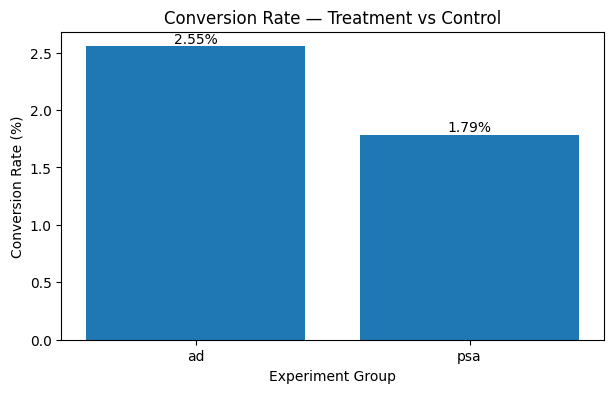

In [6]:
plt.figure(figsize=(7, 4))
plt.bar(experiment_summary["test_group"], experiment_summary["conversion_rate_pct"])
plt.title("Conversion Rate — Treatment vs Control")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

for i, value in enumerate(experiment_summary["conversion_rate_pct"]):
    plt.text(i, value, f"{value:.2f}%", ha="center", va="bottom")

plt.show()

### Allocation note

The treatment and control samples are highly unbalanced.

A formal **Sample Ratio Mismatch (SRM)** conclusion requires the intended randomization ratio. The CSV does not document that expected ratio, so this project does **not** assume a 50/50 allocation and does not label the imbalance as an SRM failure.

This is retained as an experiment-validity limitation.

## 6. Effect estimation

Statistical significance answers whether the observed difference is difficult to explain under \(H_0\). It does **not** tell us whether the effect is practically important.

### Absolute uplift

\[
\Delta = \hat p_T - \hat p_C
\]

### Relative uplift

\[
U_{rel} =
\frac{\hat p_T-\hat p_C}{\hat p_C}
\]

### Risk ratio

\[
RR = \frac{\hat p_T}{\hat p_C}
\]

where \(T\) is treatment and \(C\) is control.

In [7]:
ad = experiment_summary.loc[experiment_summary["test_group"] == "ad"].iloc[0]
psa = experiment_summary.loc[experiment_summary["test_group"] == "psa"].iloc[0]

n_ad = int(ad["users"])
n_psa = int(psa["users"])
c_ad = int(ad["conversions"])
c_psa = int(psa["conversions"])

p_ad = float(ad["conversion_rate"])
p_psa = float(psa["conversion_rate"])

absolute_uplift = p_ad - p_psa
relative_uplift = absolute_uplift / p_psa
risk_ratio = p_ad / p_psa

effect_summary = pd.DataFrame({
    "Metric": [
        "Treatment conversion",
        "Control conversion",
        "Absolute uplift (percentage points)",
        "Relative uplift",
        "Risk ratio",
    ],
    "Value": [
        f"{p_ad:.4%}",
        f"{p_psa:.4%}",
        f"{absolute_uplift * 100:.4f}",
        f"{relative_uplift:.2%}",
        f"{risk_ratio:.4f}",
    ],
})

display(effect_summary)

,Metric,Value
0,Treatment conversion,2.5547%
1,Control conversion,1.7854%
2,Absolute uplift (percentage points),0.7692
3,Relative uplift,43.09%
4,Risk ratio,1.4309


## 7. Hypothesis test

### Null hypothesis

\[
H_0: p_T=p_C
\]

### Alternative hypothesis

\[
H_1: p_T\neq p_C
\]

with:

\[
\alpha = 0.05
\]

Because the outcome is binary and the analysis compares two independent proportions, the primary inferential procedure is a **two-proportion Z-test**.

### Pooled proportion

Under \(H_0\):

\[
\hat p =
\frac{x_T+x_C}{n_T+n_C}
\]

### Standard error under \(H_0\)

\[
SE_0 =
\sqrt{
\hat p(1-\hat p)
\left(
\frac{1}{n_T}+\frac{1}{n_C}
\right)
}
\]

### Z statistic

\[
Z =
\frac{\hat p_T-\hat p_C}{SE_0}
\]

For a two-sided test, the p-value is:

\[
p = 2P(Z_{standard}\geq |z_{obs}|)
\]

In [8]:
successes = np.array([c_ad, c_psa])
observations = np.array([n_ad, n_psa])

z_stat, z_p_value = proportions_ztest(
    successes,
    observations,
    alternative="two-sided",
)

print(f"Z statistic: {z_stat:.6f}")
print(f"P-value: {z_p_value:.6e}")
print("Decision:", "Reject H0" if z_p_value < ALPHA else "Fail to reject H0")

Z statistic: 7.370078
P-value: 1.705281e-13
Decision: Reject H0


### Complementary Chi-square test

The same 2×2 relationship can also be evaluated as independence between:

- experiment group;
- conversion outcome.

The statistic is:

\[
\chi^2 =
\sum \frac{(O-E)^2}{E}
\]

where \(O\) is the observed cell count and \(E\) is the expected count under independence.

This is included as a consistency check rather than as a separate primary research question.

In [9]:
contingency = pd.crosstab(df["test_group"], df["converted"])
display(contingency)

chi2_stat, chi2_p_value, chi2_dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2_stat:.6f}")
print(f"P-value: {chi2_p_value:.6e}")
print(f"Degrees of freedom: {chi2_dof}")

converted,0,1
test_group,,
ad,550154,14423
psa,23104,420


Chi-square statistic: 54.005824
P-value: 1.998962e-13
Degrees of freedom: 1


## 8. 95% confidence interval for the absolute difference

The estimated difference is:

\[
\hat \Delta = \hat p_T-\hat p_C
\]

An unpooled standard error for the difference is:

\[
SE(\hat \Delta) =
\sqrt{
\frac{\hat p_T(1-\hat p_T)}{n_T}
+
\frac{\hat p_C(1-\hat p_C)}{n_C}
}
\]

The 95% confidence interval is:

\[
\hat \Delta
\pm
z_{0.975}SE(\hat \Delta)
\]

where \(z_{0.975}\approx1.96\).

In [10]:
z_critical = norm.ppf(0.975)

se_difference = np.sqrt(
    p_ad * (1 - p_ad) / n_ad
    +
    p_psa * (1 - p_psa) / n_psa
)

ci_low = absolute_uplift - z_critical * se_difference
ci_high = absolute_uplift + z_critical * se_difference

print(
    "95% CI for Treatment - Control:",
    f"[{ci_low * 100:.4f}, {ci_high * 100:.4f}] percentage points"
)

95% CI for Treatment - Control: [0.5951, 0.9434] percentage points


## 9. Risk ratio confidence interval

The risk ratio is:

\[
RR = \frac{\hat p_T}{\hat p_C}
\]

A confidence interval is constructed on the log scale:

\[
\log(RR) \pm z_{0.975}SE_{\log(RR)}
\]

with:

\[
SE_{\log(RR)} =
\sqrt{
\left(\frac{1}{x_T}-\frac{1}{n_T}\right)
+
\left(\frac{1}{x_C}-\frac{1}{n_C}\right)
}
\]

The endpoints are exponentiated back to the risk-ratio scale.

In [11]:
log_rr = np.log(risk_ratio)

se_log_rr = np.sqrt(
    (1 / c_ad) - (1 / n_ad)
    +
    (1 / c_psa) - (1 / n_psa)
)

rr_ci_low = np.exp(log_rr - z_critical * se_log_rr)
rr_ci_high = np.exp(log_rr + z_critical * se_log_rr)

print(f"Risk Ratio: {risk_ratio:.4f}")
print(f"95% CI: [{rr_ci_low:.4f}, {rr_ci_high:.4f}]")

Risk Ratio: 1.4309
95% CI: [1.2997, 1.5752]


## 10. Standardized effect size: Cohen's \(h\)

For two proportions:

\[
h =
2\arcsin(\sqrt{p_T})
-
2\arcsin(\sqrt{p_C})
\]

This standardizes the difference between proportions.

Common reference points are approximately:

- \(|h|=0.20\): small;
- \(|h|=0.50\): medium;
- \(|h|=0.80\): large.

These are conventions, not universal business thresholds.

In [12]:
cohen_h = proportion_effectsize(p_ad, p_psa)

print(f"Cohen's h: {cohen_h:.6f}")

if abs(cohen_h) < 0.20:
    print("Standardized effect: below the conventional 'small' benchmark.")
elif abs(cohen_h) < 0.50:
    print("Standardized effect: small.")
elif abs(cohen_h) < 0.80:
    print("Standardized effect: medium.")
else:
    print("Standardized effect: large.")

Cohen's h: 0.053003
Standardized effect: below the conventional 'small' benchmark.


## 11. Bootstrap validation

Bootstrap provides an additional uncertainty estimate without relying only on the analytical confidence-interval formula.

Because conversion is binary, each bootstrap group conversion count can be sampled from a binomial distribution using the observed empirical conversion probability.

For iteration \(b\):

\[
\hat\Delta^{(b)}
=
\hat p_T^{(b)}
-
\hat p_C^{(b)}
\]

The 2.5th and 97.5th percentiles of the bootstrap differences form a 95% percentile interval.

In [13]:
rng = np.random.default_rng(RANDOM_STATE)

bootstrap_ad = rng.binomial(n_ad, p_ad, size=N_BOOTSTRAP) / n_ad
bootstrap_psa = rng.binomial(n_psa, p_psa, size=N_BOOTSTRAP) / n_psa
bootstrap_difference = bootstrap_ad - bootstrap_psa

bootstrap_ci_low, bootstrap_ci_high = np.percentile(
    bootstrap_difference,
    [2.5, 97.5]
)

print(
    "Bootstrap 95% CI:",
    f"[{bootstrap_ci_low * 100:.4f}, "
    f"{bootstrap_ci_high * 100:.4f}] percentage points"
)

Bootstrap 95% CI: [0.5967, 0.9421] percentage points


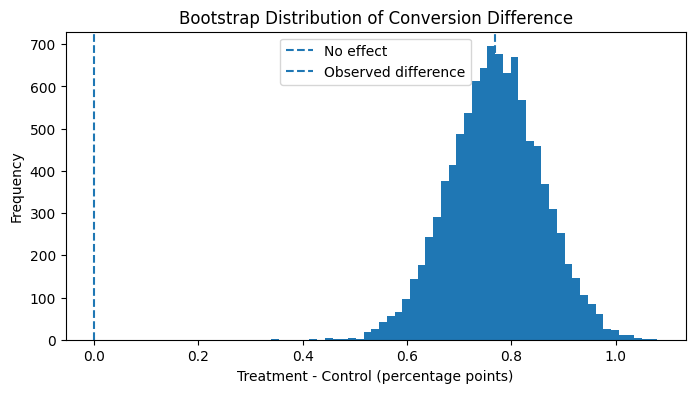

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(bootstrap_difference * 100, bins=50)
plt.axvline(0, linestyle="--", label="No effect")
plt.axvline(absolute_uplift * 100, linestyle="--", label="Observed difference")
plt.title("Bootstrap Distribution of Conversion Difference")
plt.xlabel("Treatment - Control (percentage points)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 12. Statistical power

Power is the probability of rejecting \(H_0\) when a specified non-zero effect is truly present:

\[
Power = P(\text{Reject } H_0 \mid H_1 \text{ is true})
\]

The analysis reports:

1. power associated with the observed sample sizes and observed standardized effect;
2. approximate equal-allocation sample size per group required for 80% power at the observed effect magnitude.

> **Caution:** Post-hoc power derived from the observed effect is descriptive and should not replace confidence intervals or prospective power planning.

In [15]:
power_engine = NormalIndPower()
allocation_ratio = n_psa / n_ad

observed_power = power_engine.power(
    effect_size=abs(cohen_h),
    nobs1=n_ad,
    ratio=allocation_ratio,
    alpha=ALPHA,
    alternative="two-sided",
)

required_equal_sample = power_engine.solve_power(
    effect_size=abs(cohen_h),
    power=0.80,
    alpha=ALPHA,
    ratio=1.0,
    alternative="two-sided",
)

print(f"Observed power: {observed_power:.6f}")
print(
    "Approx. required sample per group for 80% power "
    f"at the observed effect: {np.ceil(required_equal_sample):,.0f}"
)

Observed power: 1.000000
Approx. required sample per group for 80% power at the observed effect: 5,588


## 13. Behavioral exploration

The variables `total_ads`, `most_ads_day`, and `most_ads_hour` are useful for exploratory behavioral analysis.

However, they should **not** automatically be interpreted as randomized treatment variables.

For example, an association between higher exposure and conversion does not prove that additional exposure caused the conversion.

In [16]:
bins = [0, 10, 25, 50, 100, np.inf]
labels = ["1-10", "11-25", "26-50", "51-100", "100+"]

df["exposure_band"] = pd.cut(
    df["total_ads"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

exposure_analysis = (
    df.groupby("exposure_band", observed=False)
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean"),
        avg_ads=("total_ads", "mean"),
    )
    .reset_index()
)

exposure_analysis["conversion_rate_pct"] = exposure_analysis["conversion_rate"] * 100

display(exposure_analysis)

,exposure_band,users,conversions,conversion_rate,avg_ads,conversion_rate_pct
0,1-10,260775,858,0.003290,4.204548,0.329019
1,11-25,169247,1720,0.010163,17.203484,1.016266
2,26-50,89013,3124,0.035096,35.482401,3.509600
3,51-100,46002,5242,0.113952,69.384896,11.395157
4,100+,23064,3899,0.169051,183.787027,16.905134


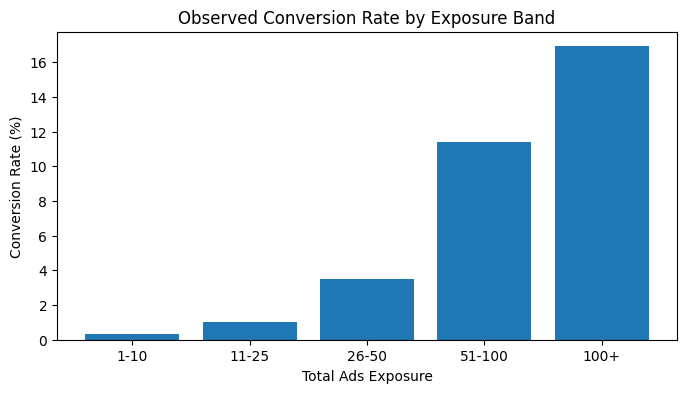

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(
    exposure_analysis["exposure_band"].astype(str),
    exposure_analysis["conversion_rate_pct"]
)
plt.title("Observed Conversion Rate by Exposure Band")
plt.xlabel("Total Ads Exposure")
plt.ylabel("Conversion Rate (%)")
plt.show()

In [18]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

conversion_by_day = (
    df.groupby("most_ads_day")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean"),
        avg_ads=("total_ads", "mean"),
    )
    .reindex(day_order)
    .reset_index()
)

conversion_by_day["conversion_rate_pct"] = (
    conversion_by_day["conversion_rate"] * 100
)

display(conversion_by_day)

,most_ads_day,users,conversions,conversion_rate,avg_ads,conversion_rate_pct
0,Monday,87073,2857,0.032812,25.328517,3.281155
1,Tuesday,77479,2312,0.029840,23.925464,2.984034
2,Wednesday,80908,2018,0.024942,24.539205,2.494191
3,Thursday,82982,1790,0.021571,23.428852,2.157094
4,Friday,92608,2057,0.022212,26.612129,2.221190
5,Saturday,81660,1719,0.021051,25.227663,2.105070
6,Sunday,85391,2090,0.024476,24.403661,2.447565


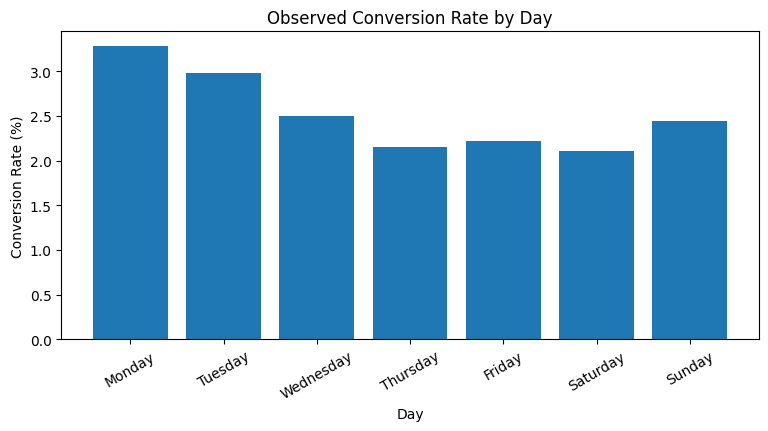

In [19]:
plt.figure(figsize=(9, 4))
plt.bar(
    conversion_by_day["most_ads_day"],
    conversion_by_day["conversion_rate_pct"]
)
plt.title("Observed Conversion Rate by Day")
plt.xlabel("Day")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [20]:
conversion_by_hour = (
    df.groupby("most_ads_hour")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean"),
        avg_ads=("total_ads", "mean"),
    )
    .reset_index()
    .sort_values("most_ads_hour")
)

conversion_by_hour["conversion_rate_pct"] = (
    conversion_by_hour["conversion_rate"] * 100
)

display(conversion_by_hour)

,most_ads_hour,users,conversions,conversion_rate,avg_ads,conversion_rate_pct
0,0,5536,102,0.018425,22.778902,1.842486
1,1,4802,62,0.012911,25.179925,1.291129
2,2,5333,39,0.007313,24.770111,0.731296
3,3,2679,28,0.010452,22.730870,1.045166
4,4,722,11,0.015235,33.412742,1.523546
5,5,765,16,0.020915,43.648366,2.091503
6,6,2068,46,0.022244,41.843327,2.224371
7,7,6405,116,0.018111,31.215457,1.811085
8,8,17627,344,0.019516,24.039655,1.951552
9,9,31004,595,0.019191,23.486840,1.919107


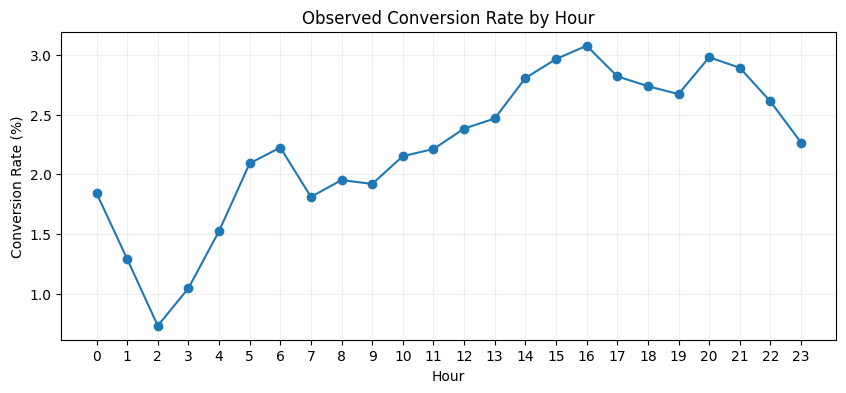

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(
    conversion_by_hour["most_ads_hour"],
    conversion_by_hour["conversion_rate_pct"],
    marker="o"
)
plt.title("Observed Conversion Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate (%)")
plt.xticks(range(24))
plt.grid(alpha=0.2)
plt.show()

## 14. Logistic regression

A treatment-only logistic model provides a complementary representation of the binary outcome:

\[
\log
\left(
\frac{P(Y=1)}{1-P(Y=1)}
\right)
=
\beta_0+\beta_1T
\]

where:

\[
T =
\begin{cases}
1 & \text{treatment (`ad`)}\\
0 & \text{control (`psa`)}
\end{cases}
\]

Exponentiating the treatment coefficient yields an odds ratio:

\[
OR=e^{\beta_1}
\]

An \(OR>1\) indicates higher observed odds of conversion in treatment than control.

Only treatment is included in the primary model. Variables such as exposure may occur downstream of treatment and are not automatically valid adjustment covariates.

In [22]:
regression_df = df.copy()
regression_df["treatment"] = (
    regression_df["test_group"] == "ad"
).astype(int)

logit_model = smf.logit(
    "converted ~ treatment",
    data=regression_df
).fit(disp=False)

print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588099
Method:                           MLE   Df Model:                            1
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:               0.0004342
Time:                        04:29:30   Log-Likelihood:                -69237.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                 8.800e-15
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.0075      0.049    -81.393      0.000      -4.104      -3.911
treatment      0.3661      0.050      7.329      0.000       0.268       0.464


In [23]:
odds_ratio = np.exp(logit_model.params["treatment"])
or_ci = np.exp(logit_model.conf_int().loc["treatment"])

print(f"Treatment odds ratio: {odds_ratio:.4f}")
print(f"95% CI: [{or_ci.iloc[0]:.4f}, {or_ci.iloc[1]:.4f}]")

Treatment odds ratio: 1.4421
95% CI: [1.3076, 1.5905]


## 15. Experiment decision

The decision framework combines:

1. statistical significance;
2. 95% confidence interval;
3. absolute uplift;
4. relative uplift;
5. risk ratio;
6. standardized effect size;
7. experiment validity.

### Decision rule

\[
\text{Reject }H_0 \text{ if } p<0.05
\]

The statistical conclusion is not equivalent to a UX rollout decision. A production UX experiment would also require pre-defined guardrail metrics such as error rate, effort, accessibility, and abandonment.

In [24]:
decision_table = pd.DataFrame({
    "Metric": [
        "Treatment conversion rate",
        "Control conversion rate",
        "Absolute uplift",
        "Relative uplift",
        "Z-test p-value",
        "95% CI low",
        "95% CI high",
        "Risk ratio",
        "Cohen's h",
        "Observed power",
        "Logistic odds ratio",
    ],
    "Value": [
        p_ad,
        p_psa,
        absolute_uplift,
        relative_uplift,
        z_p_value,
        ci_low,
        ci_high,
        risk_ratio,
        cohen_h,
        observed_power,
        odds_ratio,
    ],
})

display(decision_table)

print("\nStatistical decision:", "Reject H0" if z_p_value < ALPHA else "Fail to reject H0")

,Metric,Value
0,Treatment conversion rate,0.025547
1,Control conversion rate,0.017854
2,Absolute uplift,0.007692
3,Relative uplift,0.430851
4,Z-test p-value,0.000000
5,95% CI low,0.005951
6,95% CI high,0.009434
7,Risk ratio,1.430851
8,Cohen's h,0.053003
9,Observed power,1.000000



Statistical decision: Reject H0


### Interpretation

The treatment group has a higher observed conversion rate than the control group.

The two-proportion Z-test provides strong evidence against the null hypothesis, and the 95% confidence interval for the absolute difference does not include zero. The bootstrap interval is consistent with the analytical interval.

At the same time, Cohen's \(h\) indicates that the standardized effect is small. This illustrates an important experimentation principle:

> **Statistical significance is not the same as practical significance.**

The relative uplift appears large because the baseline conversion rate is low, while the absolute difference remains below one percentage point.

A product decision should therefore consider both the uncertainty around the effect and the practical value of the absolute change.

## 16. Research limitations

- The CSV does not document the original randomization mechanism.
- The intended treatment/control allocation ratio is not available in the file.
- A formal SRM conclusion is therefore not made.
- The public dataset does not contain UX-specific guardrails such as task completion, error rate, CES, SUS, or time-on-task.
- Exposure/day/hour analyses are observational and are not interpreted as randomized causal effects.
- Post-hoc power is descriptive and should not replace prospective experiment planning.
- The conceptual UX prototypes in this portfolio are not the source of the public experiment observations.

## 17. UX experimentation transfer

The statistical framework can be transferred to a UX feature experiment.

### Conceptual UX hypothesis

> Increasing the visual prominence and action clarity of the primary checkout CTA will improve checkout completion without increasing user effort or errors.

### Variant A

Baseline checkout experience.

### Variant B

Proposed checkout experience with:

- clearer CTA hierarchy;
- explicit next-step wording;
- clearer progress;
- reduced competing visual emphasis.

### Metrics for a real UX experiment

**Primary**
- Checkout completion rate.

**Secondary**
- Task completion rate.
- Time on task.

**Guardrails**
- Error rate.
- Customer Effort Score.
- Accessibility issues.
- Abandonment.

The UX decision should combine behavioral outcome improvement with guardrail performance.

## 18. Conclusion

This project demonstrates an end-to-end experiment-evaluation workflow:

\[
\text{Data Quality}
\rightarrow
\text{Experiment Definition}
\rightarrow
\text{Effect Estimation}
\rightarrow
\text{Inference}
\rightarrow
\text{Uncertainty}
\rightarrow
\text{Decision}
\]

The public dataset provides strong statistical evidence of a difference in conversion between treatment and control. The analysis also shows why effect magnitude, confidence intervals, validity assumptions, and guardrail metrics are required before turning statistical evidence into a product or UX decision.

## 19. Export analytical outputs

This final cell recreates the CSV/JSON files consumed by the future experiment dashboard.

In [25]:
# Determine repository root when running from the standard project layout.
if DATA_PATH.parent.name == "raw":
    PROJECT_ROOT = DATA_PATH.parents[2]
else:
    PROJECT_ROOT = Path("/content/ux_ab_testing_analysis")

PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

experiment_summary.to_csv(PROCESSED / "experiment_summary.csv", index=False)
exposure_analysis.to_csv(PROCESSED / "exposure_analysis.csv", index=False)
conversion_by_day.to_csv(PROCESSED / "conversion_by_day.csv", index=False)
conversion_by_hour.to_csv(PROCESSED / "conversion_by_hour.csv", index=False)

statistical_results = pd.DataFrame({
    "metric": [
        "treatment_conversion_rate",
        "control_conversion_rate",
        "absolute_uplift",
        "relative_uplift",
        "risk_ratio",
        "risk_ratio_ci_low",
        "risk_ratio_ci_high",
        "z_statistic",
        "z_p_value",
        "chi_square",
        "chi_square_p_value",
        "chi_square_dof",
        "ci_difference_low",
        "ci_difference_high",
        "bootstrap_ci_low",
        "bootstrap_ci_high",
        "cohen_h",
        "observed_power",
        "required_equal_sample_80_power",
        "logistic_odds_ratio",
        "logistic_or_ci_low",
        "logistic_or_ci_high",
    ],
    "value": [
        p_ad,
        p_psa,
        absolute_uplift,
        relative_uplift,
        risk_ratio,
        rr_ci_low,
        rr_ci_high,
        z_stat,
        z_p_value,
        chi2_stat,
        chi2_p_value,
        chi2_dof,
        ci_low,
        ci_high,
        bootstrap_ci_low,
        bootstrap_ci_high,
        cohen_h,
        observed_power,
        np.ceil(required_equal_sample),
        odds_ratio,
        or_ci.iloc[0],
        or_ci.iloc[1],
    ],
})

statistical_results.to_csv(
    PROCESSED / "statistical_results.csv",
    index=False
)

with open(PROCESSED / "experiment_decision.json", "w", encoding="utf-8") as f:
    json.dump({
        "alpha": ALPHA,
        "primary_test": "two-proportion z-test",
        "decision": "Reject H0" if z_p_value < ALPHA else "Fail to reject H0",
        "statistically_significant": bool(z_p_value < ALPHA),
        "methodological_note": (
            "Causal interpretation depends on confirmation of the original "
            "randomization mechanism and intended allocation ratio."
        ),
    }, f, indent=2)

with open(PROCESSED / "data_quality.json", "w", encoding="utf-8") as f:
    json.dump({
        "rows": int(len(df)),
        "unique_users": int(df["user_id"].nunique()),
        "duplicate_rows": int(df.duplicated().sum()),
        "duplicate_user_ids": int(df["user_id"].duplicated().sum()),
        "missing_values": int(df.isna().sum().sum()),
        "groups": sorted(df["test_group"].unique().tolist()),
        "converted_values": sorted(df["converted"].unique().tolist()),
    }, f, indent=2)

print("Processed outputs exported to:", PROCESSED)
for file in sorted(PROCESSED.iterdir()):
    print("-", file.name)

Processed outputs exported to: ../data/processed
- conversion_by_day.csv
- conversion_by_hour.csv
- data_quality.json
- experiment_decision.json
- experiment_summary.csv
- exposure_analysis.csv
- statistical_results.csv
